In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df= pd.read_excel(r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\unsupervised_machine_learning\datasets\Online Retail.xlsx")

In [3]:
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
df.dropna(subset=["CustomerID"])

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


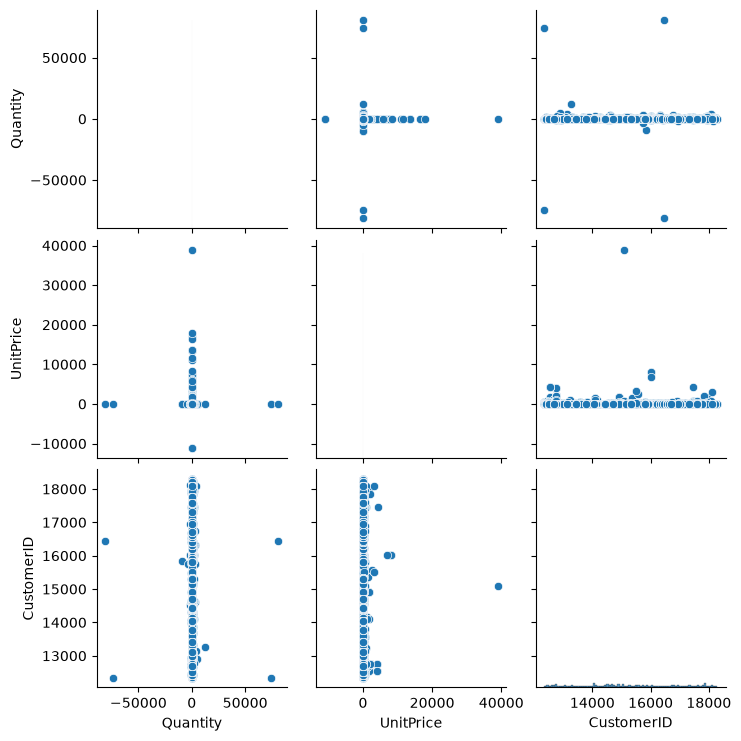

In [7]:
sns.pairplot(data=df)
plt.show()

In [11]:
print(df["InvoiceNo"].astype(str).str.startswith("C").sum())

9288


In [12]:
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

In [13]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [14]:
print(df[["Quantity", "UnitPrice", "TotalAmount"]].head())

   Quantity  UnitPrice  TotalAmount
0         6       2.55        15.30
1         6       3.39        20.34
2         8       2.75        22.00
3         6       3.39        20.34
4         6       3.39        20.34


In [15]:
df["InvoiceNo"] = pd.to_datetime(df["InvoiceDate"])
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(reference_date)

2011-12-10 12:50:00


In [16]:
rfm = df.groupby("CustomerID").agg(
    {
        "InvoiceDate": lambda x: (reference_date - x.max()).days,
        "InvoiceNo": "nunique",
        "TotalAmount": "sum"
    }
)

In [17]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

In [18]:
print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


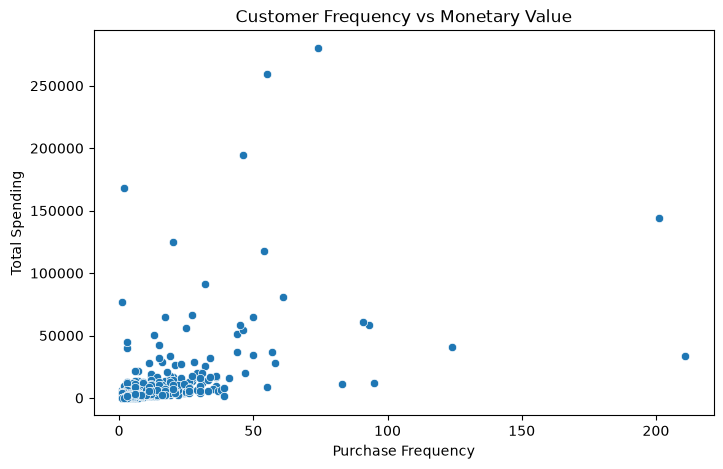

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary"
)

plt.title("Customer Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")

plt.show()

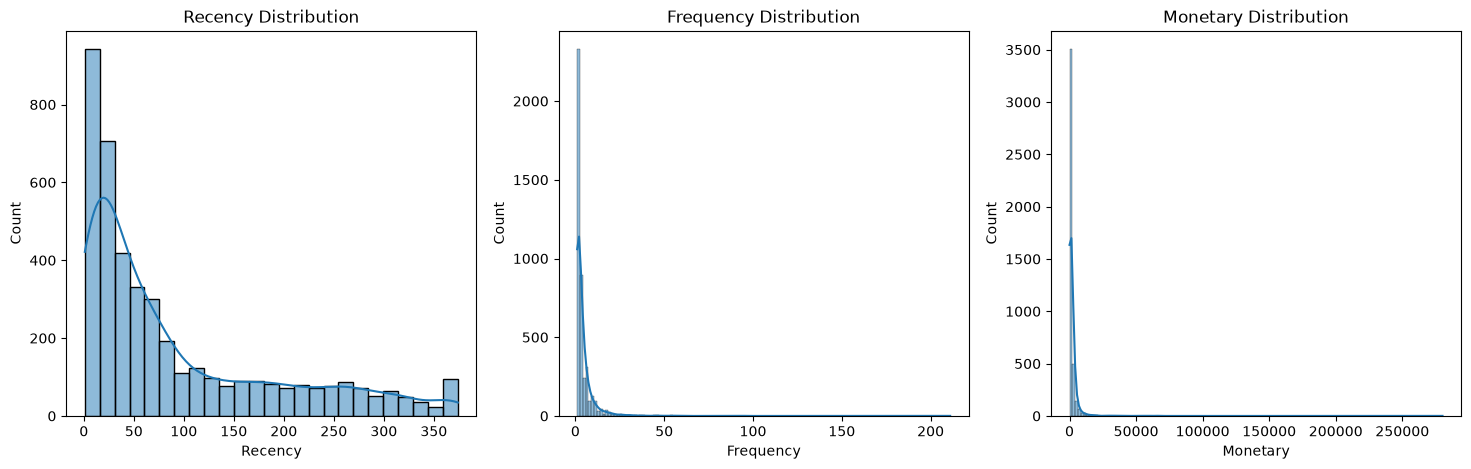

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.show()

In [21]:
rfm_log = np.log1p(rfm)

In [22]:
print(rfm_log.head())

             Recency  Frequency   Monetary
CustomerID                                
12346.0     5.789960   0.693147  11.253955
12347.0     1.098612   2.079442   8.368925
12348.0     4.330733   1.609438   7.494564
12349.0     2.995732   0.693147   7.472245
12350.0     5.739793   0.693147   5.815324


In [23]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [25]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_log.columns,
    index=rfm_log.index
)

print(rfm_scaled.head())

             Recency  Frequency  Monetary
CustomerID                               
12346.0     1.462236  -0.955932  3.696168
12347.0    -2.038611   1.079785  1.408758
12348.0     0.373310   0.389604  0.715517
12349.0    -0.622914  -0.955932  0.697821
12350.0     1.424800  -0.955932 -0.615877


In [26]:
inertia = []

k_range = range(2,11)

for k in k_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

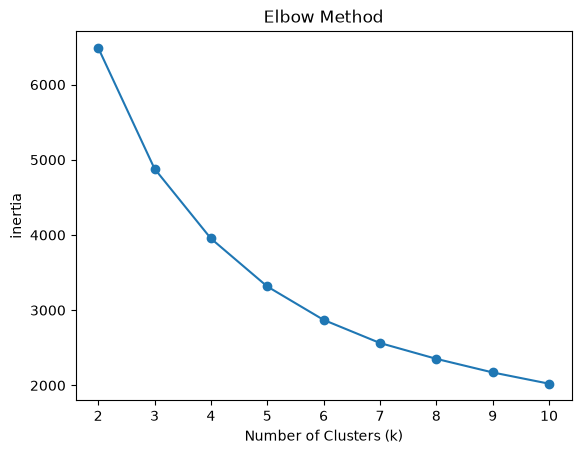

In [27]:
plt.plot(k_range,
         inertia,
         marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("inertia")
plt.title("Elbow Method")

plt.show()

In [31]:
from sklearn.metrics import silhouette_score as calculate_silhouette_score

silhouette_scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    score = calculate_silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(
        f"K = {k}, "
        f"Silhouette Score = {score:.4f}"
    )

K = 2, Silhouette Score = 0.4328
K = 3, Silhouette Score = 0.3370
K = 4, Silhouette Score = 0.3373
K = 5, Silhouette Score = 0.3155
K = 6, Silhouette Score = 0.3130
K = 7, Silhouette Score = 0.3090
K = 8, Silhouette Score = 0.3000
K = 9, Silhouette Score = 0.2812
K = 10, Silhouette Score = 0.2792


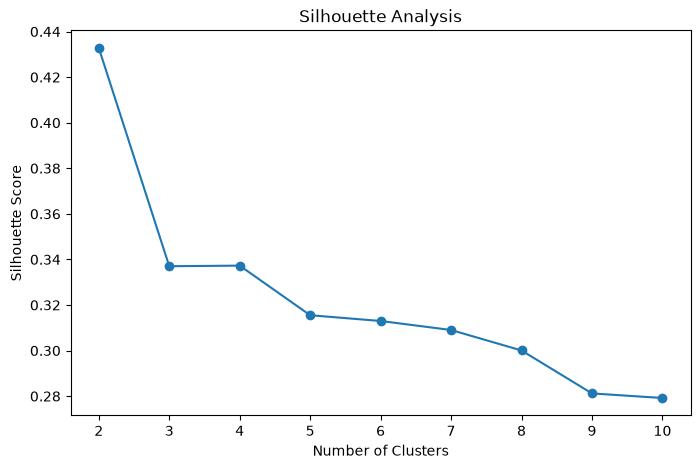

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [33]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [34]:
print(rfm.head())

            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         326          1  77183.60        3
12347.0           2          7   4310.00        2
12348.0          75          4   1797.24        3
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        1


In [37]:
cluster_summary = rfm.groupby("Cluster").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    CustomerCount=("Recency", "size")
)

In [38]:
cluster_summary = cluster_summary.rename(
    columns={
        "CustomerID": "CustomerCount"
    }
)

In [39]:
print(cluster_summary)

            Recency  Frequency     Monetary  CustomerCount
Cluster                                                   
0         17.606459   2.194976   564.448349            836
1        181.161548   1.316953   343.941383           1628
2         12.292546  13.669480  8127.940520            711
3         71.346220   4.077320  1804.662202           1164


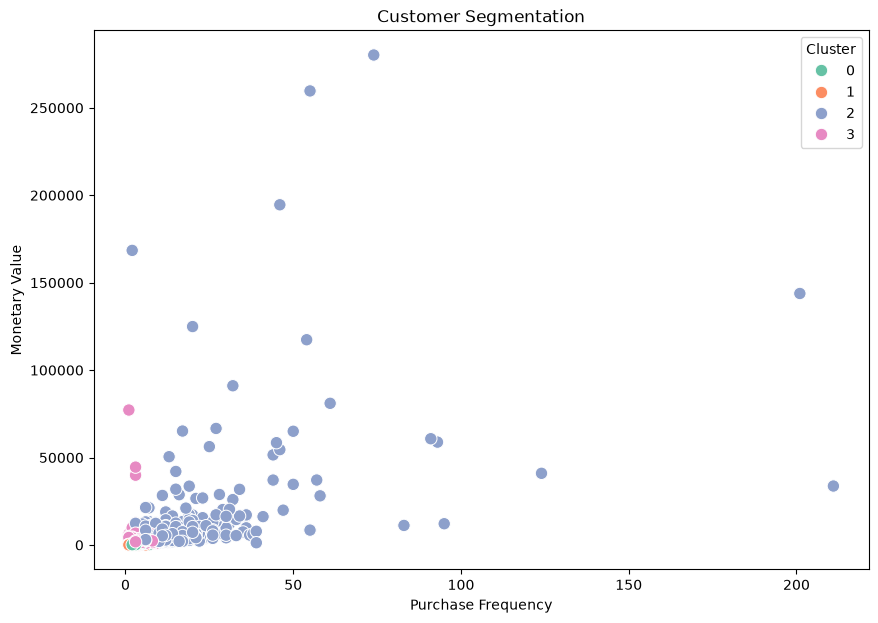

In [40]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segmentation")
plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.show()

In [41]:
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

In [42]:
pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"].values

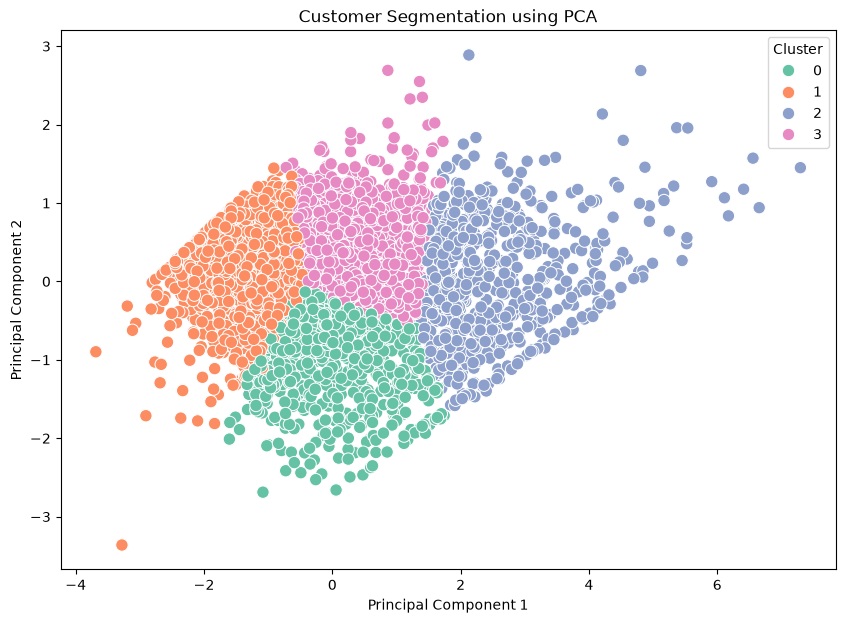

In [43]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

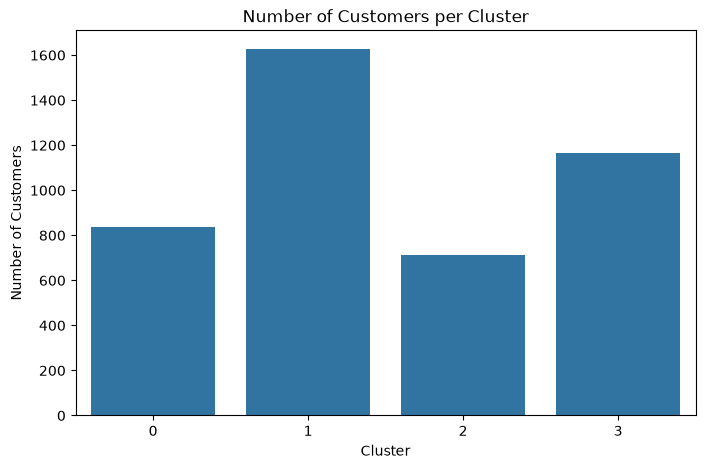

In [44]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

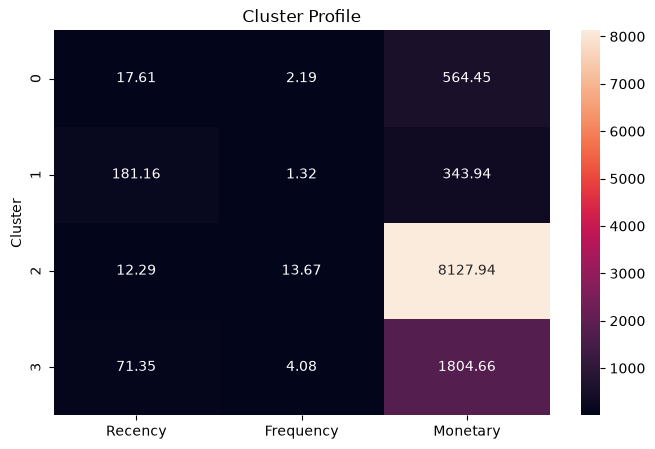

In [45]:
cluster_profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_profile,
    annot=True,
    fmt=".2f"
)

plt.title("Cluster Profile")

plt.show()

In [46]:
segment_names = {
    0: "Regular Customers",
    1: "Inactive Customers",
    2: "High Value Customers",
    3: "Frequent Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

In [47]:
print(
    rfm[
        ["Recency", "Frequency", "Monetary", "Cluster", "Segment"]
    ].head(20)
)

            Recency  Frequency  Monetary  Cluster               Segment
CustomerID                                                             
12346.0         326          1  77183.60        3    Frequent Customers
12347.0           2          7   4310.00        2  High Value Customers
12348.0          75          4   1797.24        3    Frequent Customers
12349.0          19          1   1757.55        0     Regular Customers
12350.0         310          1    334.40        1    Inactive Customers
12352.0          36          8   2506.04        3    Frequent Customers
12353.0         204          1     89.00        1    Inactive Customers
12354.0         232          1   1079.40        1    Inactive Customers
12355.0         214          1    459.40        1    Inactive Customers
12356.0          23          3   2811.43        3    Frequent Customers
12357.0          33          1   6207.67        3    Frequent Customers
12358.0           2          2   1168.06        0     Regular Cu